# Imports

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn

small useful functions

In [2]:
def gaussian_blur_tensor(x, k=15, sigma=4.0):
    ax = torch.arange(k, dtype=torch.float32, device=x.device) - k // 2
    g = torch.exp(-(ax**2) / (2 * sigma**2))
    g = g / g.sum()
    kernel2d = torch.outer(g, g)
    kernel2d = kernel2d[None, None, :, :].repeat(x.shape[1], 1, 1, 1)
    return F.conv2d(x, kernel2d, padding=k // 2, groups=x.shape[1])

def show_rgb_tensor(x, title=""):
    arr = x[0].detach().cpu().permute(1, 2, 0).numpy()
    arr = np.clip(arr, 0, 1)
    plt.figure(figsize=(8, 4))
    plt.imshow(arr)
    plt.title(title)
    plt.axis("off")
    plt.show()

def print_stats(name, t):
    print(
        f"{name} | shape={tuple(t.shape)} | "
        f"mean_abs={t.abs().mean().item():.6f} | "
        f"std={t.std().item():.6f} | "
        f"min={t.min().item():.6f} | "
        f"max={t.max().item():.6f}"
    )

# Loading the image

device = cuda
taille image : torch.Size([1, 3, 640, 960])


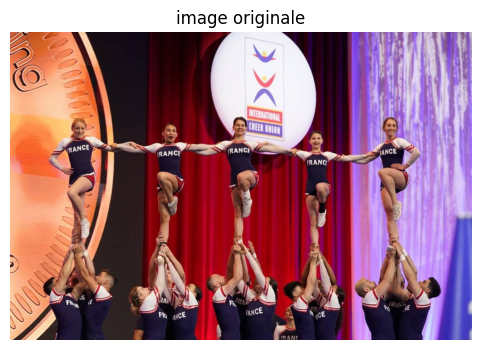

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

image_path = "demo/try.jpg"

img = Image.open(image_path).convert("RGB")
x = T.ToTensor()(img).unsqueeze(0).to(device)

print("taille image :", x.shape)
show_rgb_tensor(x, "image originale")

adding blur to the image

x | shape=(1, 3, 640, 960) | mean_abs=0.440202 | std=0.332827 | min=0.000000 | max=1.000000
x_blur | shape=(1, 3, 640, 960) | mean_abs=0.436516 | std=0.310246 | min=0.000017 | max=0.999373


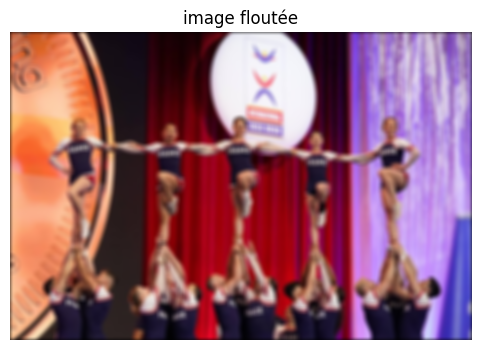

In [4]:
x_blur = gaussian_blur_tensor(x, k=15, sigma=5.0)

print_stats("x", x)
print_stats("x_blur", x_blur)

show_rgb_tensor(x_blur, "image floutée")

# Projeting the image on 32 channels

In [5]:
proj_out_channels = 32
proj = torch.nn.Conv2d(3, proj_out_channels, kernel_size=3, padding=1, bias=False).to(device)

with torch.no_grad():
    feat = proj(x_blur)

print_stats("feat", feat)
print("shape feat =", feat.shape)

feat | shape=(1, 32, 640, 960) | mean_abs=0.277556 | std=0.388667 | min=-1.701438 | max=1.044887
shape feat = torch.Size([1, 32, 640, 960])


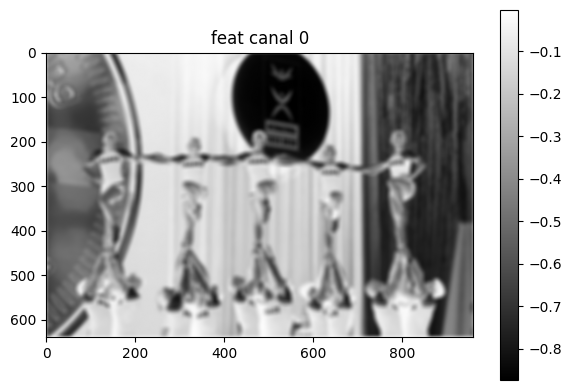

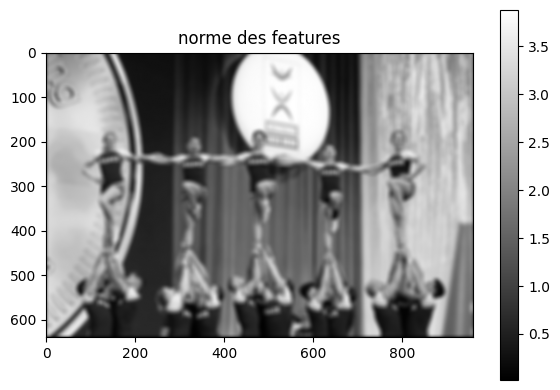

In [6]:
def show_tensor_channel(t, title="", ch=0):
    arr = t[0, ch].detach().cpu().numpy()
    plt.figure(figsize=(6, 4))
    plt.imshow(arr, cmap="gray", vmin=arr.min(), vmax=arr.max())
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_tensor_norm(t, title=""):
    arr = t[0].pow(2).sum(0).sqrt().detach().cpu().numpy()
    plt.figure(figsize=(6, 4))
    plt.imshow(arr, cmap="gray", vmin=arr.min(), vmax=arr.max())
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_tensor_channel(feat, "feat canal 0", ch=0)
show_tensor_norm(feat, "norme des features")

# Down-sampling

Copie de la classe FLC_Pooling_random_alpha_blurred de arch_util.py

In [7]:
class FLC_Pooling_random_alpha_blurred(torch.nn.Module):
    def __init__(self, channels=None, test_wo_drop_alpha=False, transpose=True,
                 test_drop_alpha=False, stop=False, half_precision=False,
                 padding="reflect"):
        super().__init__()
        self.transpose = transpose
        self.window2d = None
        self.test_wo_drop_alpha = test_wo_drop_alpha
        self.test_drop_alpha = test_drop_alpha
        self.stop = stop
        self.half_precision = half_precision
        self.padding = padding

        self.alpha = torch.nn.Parameter(torch.tensor(0.3), requires_grad=True)
        self.downsample_high = torch.nn.PixelUnshuffle(2)
        self.drop = 0

    def forward(self, x):
        device = x.device

        orig_x_size = x.shape
        orig_x = x.clone()
        x = F.pad(
            x,
            (3*x.shape[-1]//4 + 1, 3*x.shape[-1]//4,
             3*x.shape[-2]//4 + 1, 3*x.shape[-2]//4),
            mode=self.padding
        )

        if self.transpose:
            x = x.transpose(2, 3)

        in_freq = torch.fft.fftshift(torch.fft.fft2(x.to(torch.float32), norm='forward'))

        low_part = in_freq[:, :, int(x.shape[2]/4):int(x.shape[2]/4*3),
                                int(x.shape[3]/4):int(x.shape[3]/4*3)]
        low_part = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(low_part), norm='forward'))

        if self.half_precision:
            low_part = low_part.half()

        if self.transpose:
            low_part = low_part.transpose(2, 3)

        low_part = torch.cat((low_part, low_part, low_part, low_part), dim=1)

        if self.test_drop_alpha:
            return T.CenterCrop((orig_x_size[-2]//2, orig_x_size[-1]//2))(low_part)

        zeroed_high = torch.zeros_like(in_freq)
        zeroed_high[:, :, int(x.shape[2]/4):int(x.shape[2]/4*3),
                         int(x.shape[3]/4):int(x.shape[3]/4*3)] = \
            in_freq[:, :, int(x.shape[2]/4):int(x.shape[2]/4*3),
                         int(x.shape[3]/4):int(x.shape[3]/4*3)]

        zeroed_high = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(zeroed_high), norm='forward'))

        if self.half_precision:
            zeroed_high = zeroed_high.half()

        if self.transpose:
            zeroed_high = zeroed_high.transpose(2, 3)

        zeroed_high = T.CenterCrop((orig_x_size[-2], orig_x_size[-1]))(zeroed_high)

        high_part = orig_x - zeroed_high
        high_part = self.downsample_high(high_part)

        self.alpha = self.alpha.to(device)
        high_part = high_part * self.alpha

        return (
            T.CenterCrop((orig_x_size[-2]//2, orig_x_size[-1]//2))(low_part) * (1 - self.alpha)
        ) + high_part

In [8]:
class FPDownsample(torch.nn.Module):
    def __init__(self, transpose=True, half_precision=False, padding="reflect"):
        super().__init__()
        self.body = FLC_Pooling_random_alpha_blurred(
            transpose=transpose,
            half_precision=half_precision,
            padding=padding,
            test_drop_alpha=False,
            test_wo_drop_alpha=False
        )

    def forward(self, x):
        return self.body(x)

down = FPDownsample(
    transpose=True,
    half_precision=False,
    padding="reflect"
).to(device)

print("alpha initial =", down.body.alpha.item())

alpha initial = 0.30000001192092896


In [9]:
with torch.no_grad():
    y = down(feat)

print_stats("down", y)
print("shape down =", y.shape)

down | shape=(1, 128, 320, 480) | mean_abs=0.179929 | std=0.233576 | min=-0.982250 | max=1.191812
shape down = torch.Size([1, 128, 320, 480])


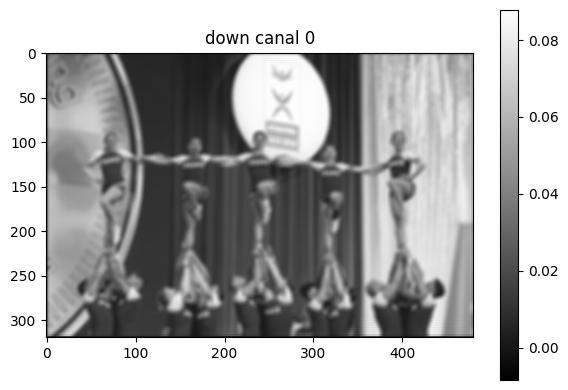

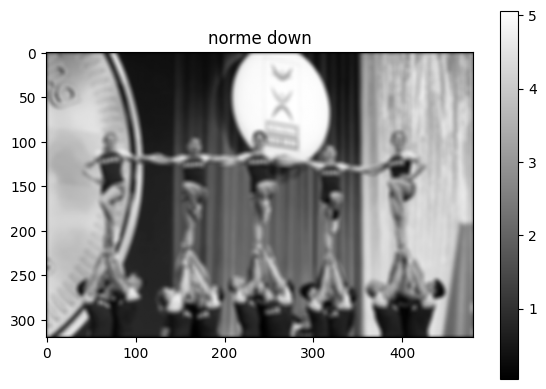

In [10]:
show_tensor_channel(y, "down canal 0", ch=0)
show_tensor_norm(y, "norme down")

In [11]:
with torch.no_grad():
    down.body.alpha.fill_(0.0)
    y_alpha0 = down(feat)

    down.body.alpha.fill_(1.0)
    y_alpha1 = down(feat)

print_stats("y_alpha0", y_alpha0)
print_stats("y_alpha1", y_alpha1)

y_alpha0 | shape=(1, 128, 320, 480) | mean_abs=0.277657 | std=0.272380 | min=0.000004 | max=1.702668
y_alpha1 | shape=(1, 128, 320, 480) | mean_abs=0.295614 | std=0.502808 | min=-3.404096 | max=0.232339


In [12]:
diff = y_alpha0 - y_alpha1

print("mean abs diff =", diff.abs().mean().item())
print("max abs diff  =", diff.abs().max().item())
print("std diff      =", diff.std().item())

mean abs diff = 0.5698542594909668
max abs diff  = 4.1385579109191895
std diff      = 0.5904811024665833


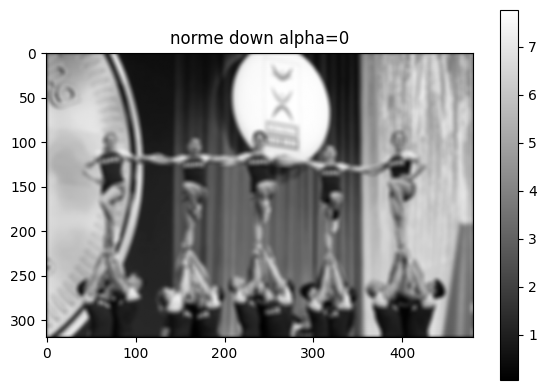

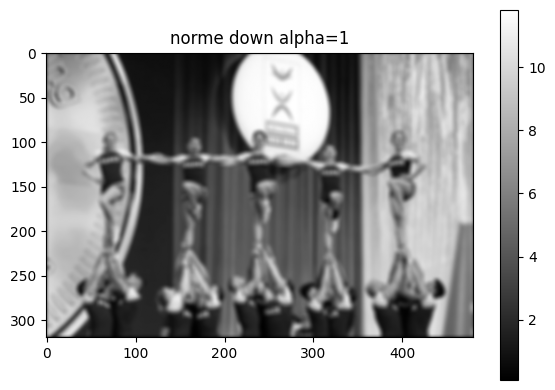

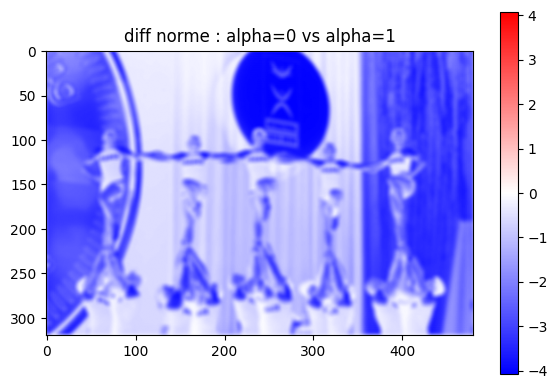

In [13]:
def show_diff_norm(a, b, title=""):
    d = (a[0].pow(2).sum(0).sqrt() - b[0].pow(2).sum(0).sqrt()).detach().cpu().numpy()
    m = np.abs(d).max()
    plt.figure(figsize=(6, 4))
    plt.imshow(d, cmap="bwr", vmin=-m, vmax=m)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_tensor_norm(y_alpha0, "norme down alpha=0")
show_tensor_norm(y_alpha1, "norme down alpha=1")
show_diff_norm(y_alpha0, y_alpha1, "diff norme : alpha=0 vs alpha=1")

# Up-sampling

In [14]:
up = torch.nn.PixelShuffle(2)

In [15]:
with torch.no_grad():
    # on remet alpha à une valeur intermédiaire
    down.body.alpha.fill_(0.3)
    y_mid = down(feat)
    z = up(y_mid)

print_stats("y_mid", y_mid)
print_stats("up", z)
print("shape up =", z.shape)

y_mid | shape=(1, 128, 320, 480) | mean_abs=0.179929 | std=0.233576 | min=-0.982250 | max=1.191812
up | shape=(1, 32, 640, 960) | mean_abs=0.179929 | std=0.233576 | min=-0.982250 | max=1.191812
shape up = torch.Size([1, 32, 640, 960])


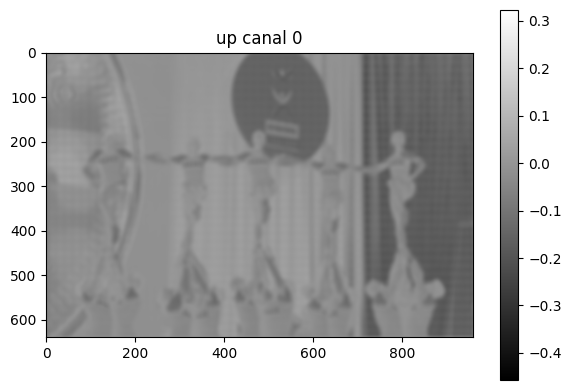

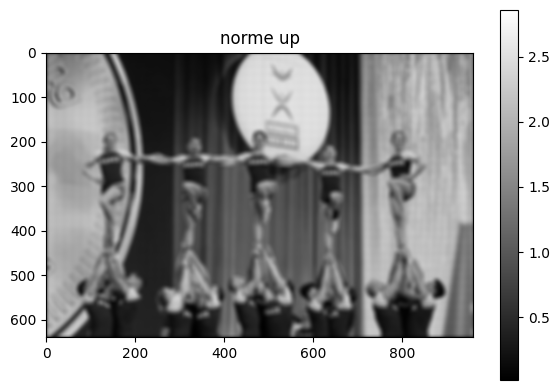

In [16]:
show_tensor_channel(z, "up canal 0", ch=0)
show_tensor_norm(z, "norme up")

Je tente de renvoyer l'image en couleurs

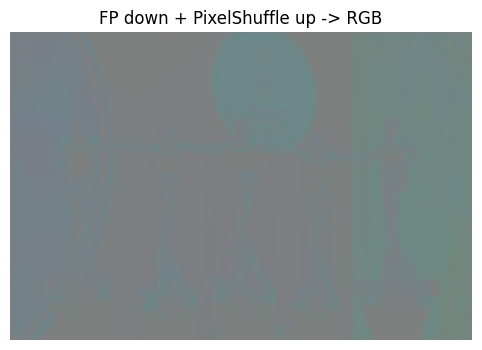

In [17]:
proj_back = torch.nn.Conv2d(32, 3, kernel_size=1, bias=False).to(device)

with torch.no_grad():
    down.body.alpha.fill_(0.3)
    y_mid = down(feat)
    z = up(y_mid)
    z_rgb = proj_back(z)

show_rgb_tensor(torch.sigmoid(z_rgb), "FP down + PixelShuffle up -> RGB")

# Up-sampling using FreqAvgUp

In [18]:
class FreqAvgUp(nn.Module):
    def __init__(self, n_feat, transpose=False):
        super().__init__()
        self.body = nn.Conv2d(n_feat, n_feat * 2, kernel_size=3, stride=1, padding=1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)
        self.shuffle = nn.PixelShuffle(2)
        self.transpose = transpose

    def forward(self, x):
        orig_dtype = x.dtype

        # same as current code: expand channels before frequency split
        x = self.body(x)   # [B, C, H, W] -> [B, 2C, H, W]
        B, C, H, W = x.shape

        if self.transpose:
            x = x.transpose(2, 3)
            H, W = W, H

        # centered FFT
        freq = torch.fft.fftshift(torch.fft.fft2(x.to(torch.float32), norm='forward'))

        # group every 4 channels
        assert C % 4 == 0, f"Expected channel dim divisible by 4, got {C}"

        low_groups = []
        low_groups_repeated = []

        for i in range(0, C, 4):
            avg = freq[:, i:i+4, :, :].mean(dim=1, keepdim=True)   # [B,1,H,W]
            low_groups.append(avg)
            low_groups_repeated.append(avg.repeat(1, 4, 1, 1))     # [B,4,H,W]

        low_freq = torch.cat(low_groups, dim=1)                     # [B,C/4,H,W]
        low_freq_repeated = torch.cat(low_groups_repeated, dim=1)   # [B,C,H,W]

        # high-frequency branch
        high_freq = freq - low_freq_repeated
        high_spatial = torch.fft.ifft2(torch.fft.ifftshift(high_freq), norm='forward').real
        high_spatial = high_spatial.to(orig_dtype)
        high_up = self.shuffle(high_spatial)                        # [B,C/4,2H,2W]

        # low-frequency branch:
        # centered zero-padding in frequency domain from HxW to 2H x 2W
        low_up_freq = torch.zeros(
            (B, low_freq.shape[1], 2 * H, 2 * W),
            dtype=low_freq.dtype,
            device=low_freq.device
        )

        low_up_freq[:, :, H//2: H//2 + H, W//2: W//2 + W] = low_freq

        low_up = torch.fft.ifft2(torch.fft.ifftshift(low_up_freq), norm='forward').real
        low_up = low_up.to(orig_dtype)

        if self.transpose:
            low_up = low_up.transpose(2, 3)
            high_up = high_up.transpose(2, 3)

        return (1 - self.beta) * low_up + self.beta * high_up

In [19]:
with torch.no_grad():
    down.body.alpha.fill_(0.3)
    y_new = down(feat)

print(y_new.shape)

up_new = FreqAvgUp(n_feat=y_new.shape[1], transpose=True).to(device)

with torch.no_grad():
    z_new = up_new(y_new)

print_stats("y_new", y_new)
print_stats("z_new", z_new)
print("z_new shape =", z_new.shape)

torch.Size([1, 128, 320, 480])
y_new | shape=(1, 128, 320, 480) | mean_abs=0.179929 | std=0.233576 | min=-0.982250 | max=1.191812
z_new | shape=(1, 64, 640, 960) | mean_abs=0.042939 | std=0.061955 | min=-0.311954 | max=0.316548
z_new shape = torch.Size([1, 64, 640, 960])


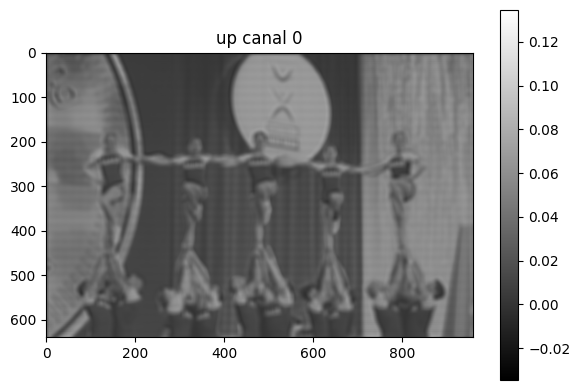

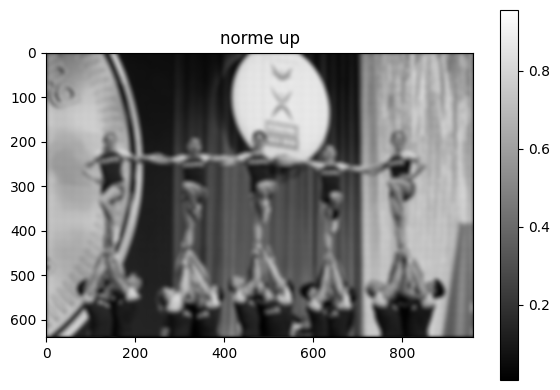

In [20]:
show_tensor_channel(z_new, "up canal 0", ch=0)
show_tensor_norm(z_new, "norme up")

# Mesure de la partie imaginaire apres la ifft2 compare a la partie reelle

In [21]:
def report_complex(name, z):
        imag_mean = z.imag.abs().mean().item()
        imag_max = z.imag.abs().max().item()
        real_mean = z.real.abs().mean().item()
        ratio = imag_mean / (real_mean + 1e-12)
        print(f"{name}:")
        print(f"  real abs mean = {real_mean:.6e}")
        print(f"  imag abs mean = {imag_mean:.6e}")
        print(f"  imag abs max  = {imag_max:.6e}")
        print(f"  imag/real mean ratio = {ratio:.6e}")

In [22]:
with torch.no_grad():
    x = down(feat)   # ou n'importe quel tenseur d'entrée de l'upsampling
    x2 = up_new.body(x)   # conv initiale de FreqAvgUp

    if up_new.transpose:
        x2_t = x2.transpose(2, 3)
    else:
        x2_t = x2

    freq = torch.fft.fftshift(torch.fft.fft2(x2_t.to(torch.float32), norm='forward'))

    B, C, H, W = freq.shape

    low_groups = []
    low_groups_repeated = []
    for i in range(0, C, 4):
        avg = freq[:, i:i+4].mean(dim=1, keepdim=True)
        low_groups.append(avg)
        low_groups_repeated.append(avg.repeat(1, 4, 1, 1))

    low_freq = torch.cat(low_groups, dim=1)
    low_freq_repeated = torch.cat(low_groups_repeated, dim=1)

    # branche haute
    high_freq = freq - low_freq_repeated
    high_ifft = torch.fft.ifft2(torch.fft.ifftshift(high_freq), norm='forward')

    # branche basse
    low_up_freq = torch.zeros(
        (B, low_freq.shape[1], 2 * H, 2 * W),
        dtype=low_freq.dtype,
        device=low_freq.device
    )
    start_h = (2 * H - H) // 2
    start_w = (2 * W - W) // 2
    low_up_freq[:, :, start_h:start_h + H, start_w:start_w + W] = low_freq

    low_ifft = torch.fft.ifft2(torch.fft.ifftshift(low_up_freq), norm='forward')

    report_complex("high_ifft", high_ifft)
    report_complex("low_ifft", low_ifft)

high_ifft:
  real abs mean = 8.405319e-02
  imag abs mean = 6.646924e-09
  imag abs max  = 1.871526e-07
  imag/real mean ratio = 7.907997e-08
low_ifft:
  real abs mean = 5.089445e-02
  imag abs mean = 8.563842e-05
  imag abs max  = 7.945886e-04
  imag/real mean ratio = 1.682667e-03


Attention : dans la partie basses frequences, la partie imaginaire importe peut-etre